# Data Splitting

## Load Library

In [1]:
# configuration, constant variable
RANDOM_STATE = 0  # consistent dengan Data Preparation
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
IMG_SIZE = (218, 178)  # original CelebA size
TARGET_SIZE = (128, 128)  # resize untuk training (lebih cepat)
BATCH_SIZE = 32

In [2]:
# load library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import os
from pathlib import Path
import pickle
from tqdm import tqdm

In [3]:
# library for splitting
from sklearn.model_selection import train_test_split

In [4]:
# library for data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array, array_to_img

2025-10-23 22:56:49.699362: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761260209.956023      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761260210.024234      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [5]:
# style and result load library
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ Libraries loaded successfully!")
print(f"Random State: {RANDOM_STATE}")
print(f"Split Ratio - Train: {TRAIN_RATIO}, Val: {VAL_RATIO}, Test: {TEST_RATIO}")

✓ Libraries loaded successfully!
Random State: 0
Split Ratio - Train: 0.7, Val: 0.15, Test: 0.15


## Load Checkpoint dari Data Preparation

In [6]:
# path ke output Data Preparation (sesuaikan dengan nama dataset anda)
PREP_OUTPUT_PATH = '/kaggle/input/data-preparation-face-recognigtion-ipynb/'
IMAGE_PATH = '/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba'

# load balanced dataframe
df_balanced = pd.read_csv(f'{PREP_OUTPUT_PATH}celeba_prepared_balanced.csv')
print(f"✓ Loaded balanced data: {len(df_balanced)} images")

# load metadata
with open(f'{PREP_OUTPUT_PATH}preparation_metadata.pkl', 'rb') as f:
    prep_metadata = pickle.load(f)

print("\n" + "="*50)
print("DATA PREPARATION SUMMARY")
print("="*50)
for key, value in prep_metadata.items():
    print(f"{key}: {value}")

# verify data
print("\n" + "="*50)
print("GENDER DISTRIBUTION")
print("="*50)
print(df_balanced['Gender'].value_counts())

# display sample
print("\nSample data:")
print(df_balanced.head())

✓ Loaded balanced data: 168868 images

DATA PREPARATION SUMMARY
total_images: 168868
gender_distribution: {'Female': 84434, 'Male': 84434}
attributes: ['Male', 'Young', 'Smiling', 'Mouth_Slightly_Open']
image_size: (178, 218)
balancing_method: undersampling

GENDER DISTRIBUTION
Gender
Female    84434
Male      84434
Name: count, dtype: int64

Sample data:
     image_id  Male  Young  Smiling  Mouth_Slightly_Open  Gender
0  080580.jpg     0      1        0                    1  Female
1  058476.jpg     0      1        1                    0  Female
2  030128.jpg     0      1        0                    1  Female
3  091961.jpg     1      1        0                    0    Male
4  134912.jpg     0      1        1                    0  Female


## Split Data to Data Train, Test, and Validation

In [7]:
# stratified splitting
# stratified, memastikan proporsi male/female sama di train, val, test

# split train 70% and temp 30%
# temp akan dibagi menjadi val 15% and test 15%
train_df, temp_df = train_test_split(
    df_balanced,
    test_size=(VAL_RATIO + TEST_RATIO),  # 0.30
    random_state=RANDOM_STATE,
    stratify=df_balanced['Gender']  # Stratified by gender
)

In [8]:
# split temp to val (50% from 30% = 15%) and test (50% from 30% = 15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,  # 50% dari temp
    random_state=RANDOM_STATE,
    stratify=temp_df['Gender']
)

In [9]:
# reset index
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [10]:
# display result splitting
print("\n" + "="*50)
print("SPLITTING DATA")
print("="*50)

print(f"\nTrain set: {len(train_df)} images ({len(train_df)/len(df_balanced)*100:.1f}%)")
print(f"Val set:   {len(val_df)} images ({len(val_df)/len(df_balanced)*100:.1f}%)")
print(f"Test set:  {len(test_df)} images ({len(test_df)/len(df_balanced)*100:.1f}%)")
print(f"Total:     {len(train_df) + len(val_df) + len(test_df)} images")

# verify stratification
print("\n" + "="*50)
print("GENDER DISTRIBUTION PER SPLIT")
print("="*50)

splits = {
    'Train': train_df,
    'Validation': val_df,
    'Test': test_df
}

for split_name, split_df in splits.items():
    gender_dist = split_df['Gender'].value_counts()
    print(f"\n{split_name}:")
    print(gender_dist)
    print(f"Female: {gender_dist['Female']/len(split_df)*100:.1f}%")
    print(f"Male: {gender_dist['Male']/len(split_df)*100:.1f}%")


SPLITTING DATA

Train set: 118207 images (70.0%)
Val set:   25330 images (15.0%)
Test set:  25331 images (15.0%)
Total:     168868 images

GENDER DISTRIBUTION PER SPLIT

Train:
Gender
Male      59104
Female    59103
Name: count, dtype: int64
Female: 50.0%
Male: 50.0%

Validation:
Gender
Female    12665
Male      12665
Name: count, dtype: int64
Female: 50.0%
Male: 50.0%

Test:
Gender
Female    12666
Male      12665
Name: count, dtype: int64
Female: 50.0%
Male: 50.0%


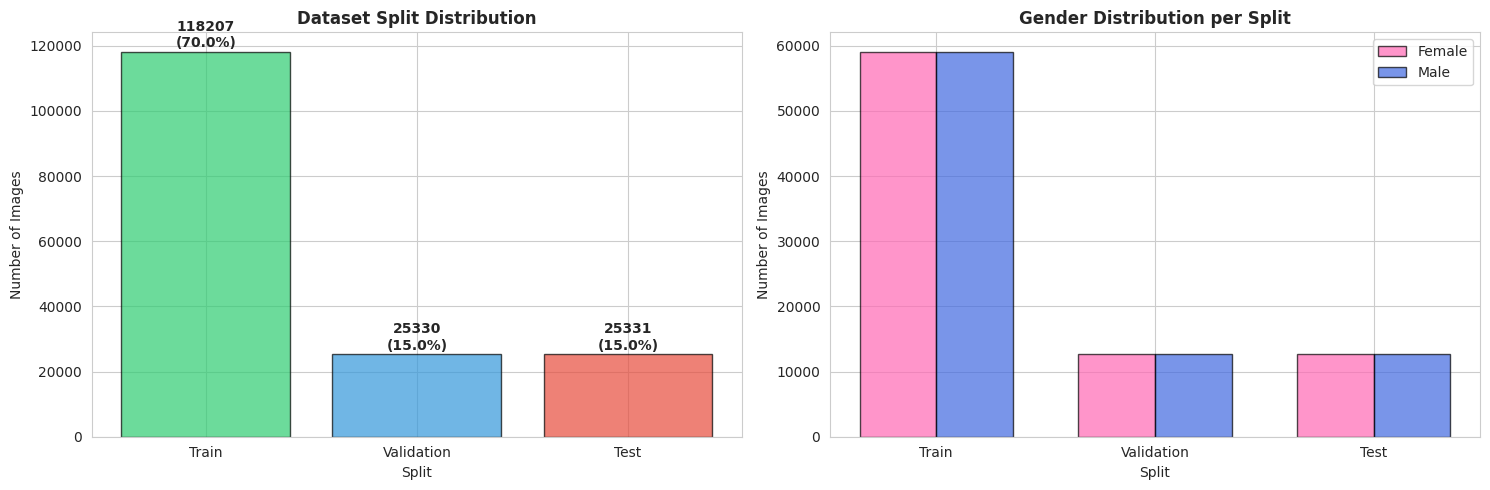

In [11]:
# visualize splitting

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# plot 1: Total per split
split_sizes = [len(train_df), len(val_df), len(test_df)]
split_labels = ['Train', 'Validation', 'Test']
colors = ['#2ecc71', '#3498db', '#e74c3c']

axes[0].bar(split_labels, split_sizes, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_title('Dataset Split Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Images')
axes[0].set_xlabel('Split')

# add value labels
for i, v in enumerate(split_sizes):
    axes[0].text(i, v + 500, f'{v}\n({v/len(df_balanced)*100:.1f}%)', 
                 ha='center', va='bottom', fontweight='bold')

# plot 2: Gender distribution per split
x = np.arange(len(split_labels))
width = 0.35

female_counts = [
    train_df[train_df['Gender']=='Female'].shape[0],
    val_df[val_df['Gender']=='Female'].shape[0],
    test_df[test_df['Gender']=='Female'].shape[0]
]

male_counts = [
    train_df[train_df['Gender']=='Male'].shape[0],
    val_df[val_df['Gender']=='Male'].shape[0],
    test_df[test_df['Gender']=='Male'].shape[0]
]

axes[1].bar(x - width/2, female_counts, width, label='Female', color='#FF69B4', alpha=0.7, edgecolor='black')
axes[1].bar(x + width/2, male_counts, width, label='Male', color='#4169E1', alpha=0.7, edgecolor='black')

axes[1].set_title('Gender Distribution per Split', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Images')
axes[1].set_xlabel('Split')
axes[1].set_xticks(x)
axes[1].set_xticklabels(split_labels)
axes[1].legend()

plt.tight_layout()
plt.show()

## Create Data Augmentation for Data Train and Validation

In [12]:
# data augmentation generators

# augmentation untuk TRAIN (Agresif)
train_datagen = ImageDataGenerator(
    rescale=1./255,              # normalize pixel values [0,1]
    rotation_range=20,           # rotate ±20 degrees
    width_shift_range=0.2,       # shift horizontal 20%
    height_shift_range=0.2,      # shift vertical 20%
    shear_range=0.2,             # shear transformation
    zoom_range=0.2,              # zoom in/out 20%
    horizontal_flip=True,        # flip horizontal (penting untuk faces)
    fill_mode='nearest'          # fill pixels setelah transformasi
)

In [13]:
# augmentation for validation
val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [14]:
# augmentation for testing
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [15]:
print("✓ Data augmentation generators created")
print("\nTrain augmentation:")
print("  - Rotation: ±20°")
print("  - Shift: ±20%")
print("  - Zoom: ±20%")
print("  - Horizontal flip: Yes")
print("  - Shear: 0.2")
print("\nValidation augmentation:")
print("  - Only rescaling (no augmentation)")
print("\nTest augmentation:")
print("  - Only rescaling (no augmentation)")

✓ Data augmentation generators created

Train augmentation:
  - Rotation: ±20°
  - Shift: ±20%
  - Zoom: ±20%
  - Horizontal flip: Yes
  - Shear: 0.2

Validation augmentation:
  - Only rescaling (no augmentation)

Test augmentation:
  - Only rescaling (no augmentation)



Generating augmented examples from: 182115.jpg
Gender: Female


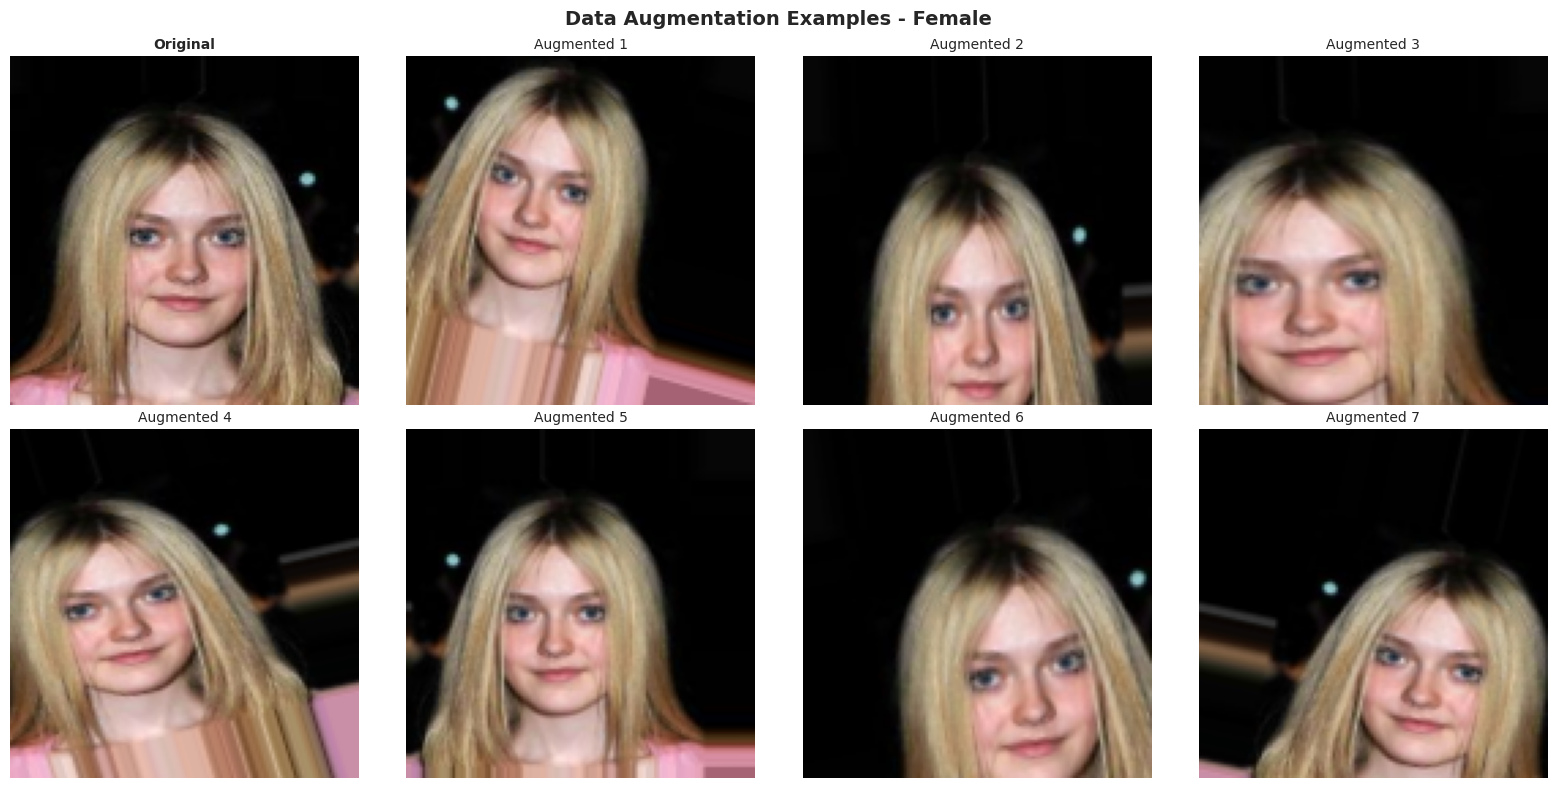

In [16]:
# visualize augmentation example

# sample image
sample_row = train_df.iloc[0]
sample_img_path = os.path.join(IMAGE_PATH, sample_row['image_id'])
sample_img = Image.open(sample_img_path)
sample_img_resized = sample_img.resize(TARGET_SIZE)

# convert to array
img_array = img_to_array(sample_img_resized)
img_array = img_array.reshape((1,) + img_array.shape)

# generate augmented images
print(f"\nGenerating augmented examples from: {sample_row['image_id']}")
print(f"Gender: {sample_row['Gender']}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

# original image
axes[0].imshow(sample_img_resized)
axes[0].set_title('Original', fontsize=10, fontweight='bold')
axes[0].axis('off')

# generate 7 augmented versions
i = 1
for batch in train_datagen.flow(img_array, batch_size=1):
    aug_img = array_to_img(batch[0])
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Augmented {i}', fontsize=10)
    axes[i].axis('off')
    i += 1
    if i >= 8:  # stop after 7 augmented images
        break

plt.suptitle(f'Data Augmentation Examples - {sample_row["Gender"]}', 
             y=0.98, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# prepare data for generators

# tambahkan full path ke dataframe
train_df['filepath'] = train_df['image_id'].apply(lambda x: os.path.join(IMAGE_PATH, x))
val_df['filepath'] = val_df['image_id'].apply(lambda x: os.path.join(IMAGE_PATH, x))
test_df['filepath'] = test_df['image_id'].apply(lambda x: os.path.join(IMAGE_PATH, x))

# convert gender label ke format untuk generator
# male = 1, Female = 0 (sudah ada kolom 'Male')
train_df['label'] = train_df['Male'].astype(str)
val_df['label'] = val_df['Male'].astype(str)
test_df['label'] = test_df['Male'].astype(str)

print("\nDataframe prepared for generators:")
print(train_df[['image_id', 'Gender', 'label']].head())


Dataframe prepared for generators:
     image_id  Gender label
0  182115.jpg  Female     0
1  186315.jpg  Female     0
2  109946.jpg    Male     1
3  200769.jpg  Female     0
4  194914.jpg    Male     1


In [18]:
# create generators

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',  # Binary classification (Male/Female)
    shuffle=True,
    seed=RANDOM_STATE
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False  # Don't shuffle validation
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False  # Don't shuffle test
)

print("\n" + "="*50)
print("GENERATORS CREATED")
print("="*50)
print(f"Train generator: {train_generator.samples} samples, {len(train_generator)} batches")
print(f"Val generator:   {val_generator.samples} samples, {len(val_generator)} batches")
print(f"Test generator:  {test_generator.samples} samples, {len(test_generator)} batches")
print(f"\nClass indices: {train_generator.class_indices}")

Found 118207 validated image filenames belonging to 2 classes.
Found 25330 validated image filenames belonging to 2 classes.
Found 25331 validated image filenames belonging to 2 classes.

GENERATORS CREATED
Train generator: 118207 samples, 3694 batches
Val generator:   25330 samples, 792 batches
Test generator:  25331 samples, 792 batches

Class indices: {'0': 0, '1': 1}



GENERATOR OUTPUT VERIFICATION
Batch shape: (32, 128, 128, 3)
Labels shape: (32,)
Pixel value range: [0.000, 1.000]
Labels in batch: [1. 0. 1. 1. 0. 1. 1. 0. 0. 1.]


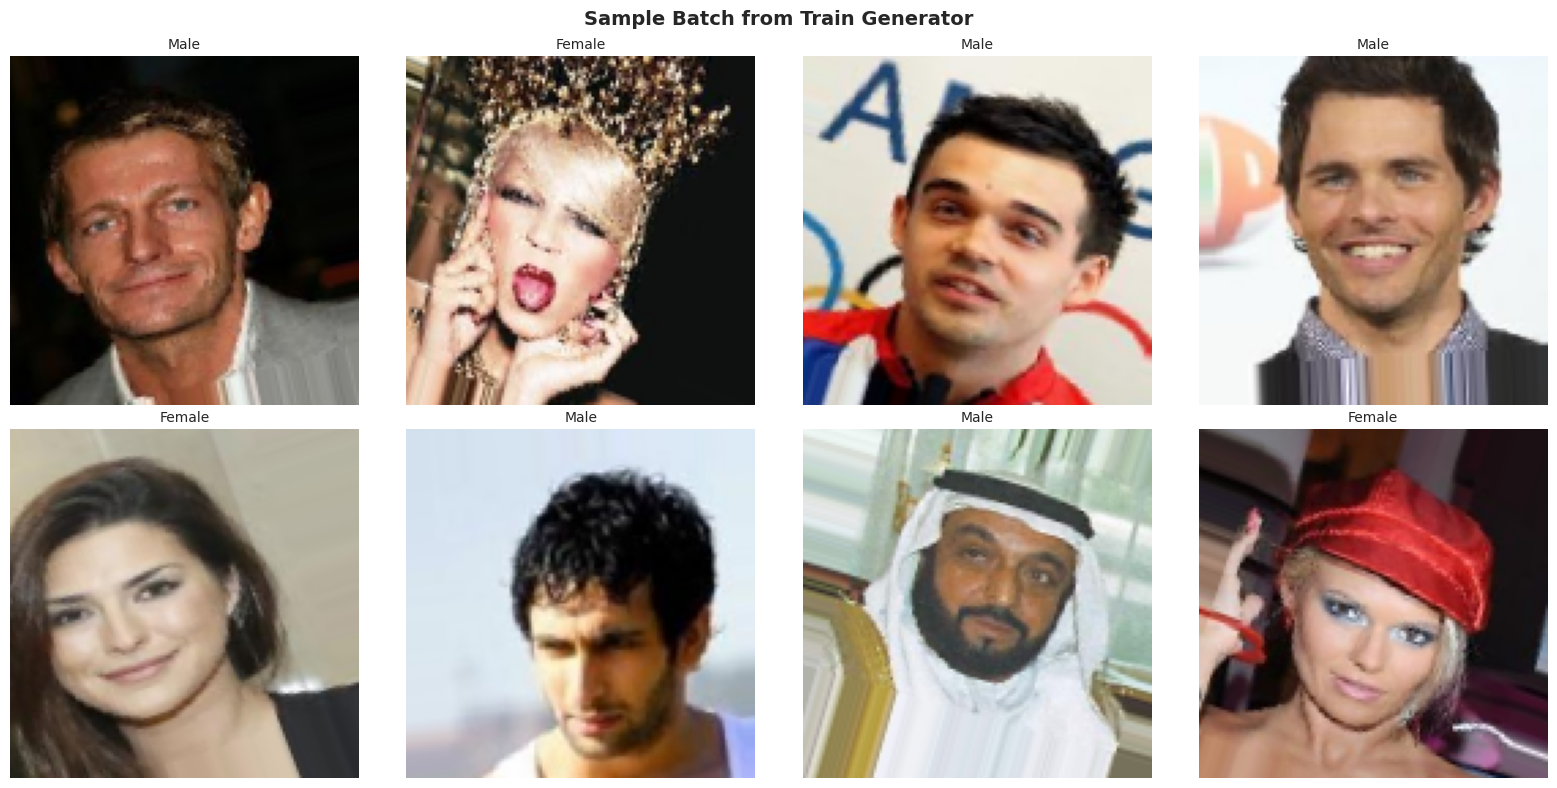

In [19]:
# test generator output

# ambil 1 batch dari train generator
X_sample, y_sample = next(train_generator)

print("\n" + "="*50)
print("GENERATOR OUTPUT VERIFICATION")
print("="*50)
print(f"Batch shape: {X_sample.shape}")  # (batch_size, height, width, channels)
print(f"Labels shape: {y_sample.shape}")  # (batch_size,)
print(f"Pixel value range: [{X_sample.min():.3f}, {X_sample.max():.3f}]")
print(f"Labels in batch: {y_sample[:10]}")  # First 10 labels

# visualize batch
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i in range(8):
    axes[i].imshow(X_sample[i])
    label_text = 'Male' if y_sample[i] == 1 else 'Female'
    axes[i].set_title(f'{label_text}', fontsize=10)
    axes[i].axis('off')

plt.suptitle('Sample Batch from Train Generator', y=0.98, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# save splitting checkpoint

output_path = '/kaggle/working/'

# save dataframes
train_df.to_csv(f'{output_path}train_split.csv', index=False)
val_df.to_csv(f'{output_path}val_split.csv', index=False)
test_df.to_csv(f'{output_path}test_split.csv', index=False)
print("✓ Saved split dataframes")

# save splitting metadata
split_metadata = {
    'random_state': RANDOM_STATE,
    'train_size': len(train_df),
    'val_size': len(val_df),
    'test_size': len(test_df),
    'train_ratio': TRAIN_RATIO,
    'val_ratio': VAL_RATIO,
    'test_ratio': TEST_RATIO,
    'target_size': TARGET_SIZE,
    'batch_size': BATCH_SIZE,
    'augmentation_config': {
        'train': {
            'rotation_range': 20,
            'width_shift_range': 0.2,
            'height_shift_range': 0.2,
            'shear_range': 0.2,
            'zoom_range': 0.2,
            'horizontal_flip': True
        },
        'val': 'rescale_only',
        'test': 'rescale_only'
    },
    'class_indices': train_generator.class_indices,
    'train_gender_dist': train_df['Gender'].value_counts().to_dict(),
    'val_gender_dist': val_df['Gender'].value_counts().to_dict(),
    'test_gender_dist': test_df['Gender'].value_counts().to_dict()
}

with open(f'{output_path}split_metadata.pkl', 'wb') as f:
    pickle.dump(split_metadata, f)
print("✓ Saved split metadata")

# save generator configuration (untuk recreate di notebook berikutnya)
generator_config = {
    'target_size': TARGET_SIZE,
    'batch_size': BATCH_SIZE,
    'class_mode': 'binary',
    'random_state': RANDOM_STATE
}

with open(f'{output_path}generator_config.pkl', 'wb') as f:
    pickle.dump(generator_config, f)
print("✓ Saved generator config")

# 4. Print summary
print("\n" + "="*50)
print("DATA SPLITTING COMPLETED!")
print("="*50)
print(f"\nOutput files saved to: /kaggle/working/")
print("- train_split.csv")
print("- val_split.csv")
print("- test_split.csv")
print("- split_metadata.pkl")
print("- generator_config.pkl")

print("\n" + "="*50)
print("SUMMARY")
print("="*50)
for key, value in split_metadata.items():
    if key not in ['augmentation_config', 'train_gender_dist', 'val_gender_dist', 'test_gender_dist']:
        print(f"{key}: {value}")

✓ Saved split dataframes
✓ Saved split metadata
✓ Saved generator config

DATA SPLITTING COMPLETED!

Output files saved to: /kaggle/working/
- train_split.csv
- val_split.csv
- test_split.csv
- split_metadata.pkl
- generator_config.pkl

SUMMARY
random_state: 0
train_size: 118207
val_size: 25330
test_size: 25331
train_ratio: 0.7
val_ratio: 0.15
test_ratio: 0.15
target_size: (128, 128)
batch_size: 32
class_indices: {'0': 0, '1': 1}
